# line simulation

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
from pprint import pprint
import pickle
import heapq
from collections import deque
from tqdm import tqdm

In [7]:
with open(r'..\data\blue_network.pkl', 'rb') as f:
    blue_network = pickle.load(f)

In [8]:
pprint(blue_network)

{'Airport': {False: {'dwell_params': {'c': 7.79,
                                      'd': 53.19,
                                      'loc': 0.0,
                                      'scale': 27.2},
                     'next_station': {'name': 'Maverick',
                                      'travel_params': {'c': 16.67,
                                                        'd': 5.81,
                                                        'loc': 0.0,
                                                        'scale': 87.0}}},
             True: {'dwell_params': {'c': 9.01,
                                     'd': 10.99,
                                     'loc': 0.0,
                                     'scale': 34.24},
                    'next_station': {'name': 'Wood Island',
                                     'travel_params': {'c': 17.0,
                                                       'd': 103.62,
                                                       'loc': 0.0,
 

In [ ]:
def marey_diagram(trains, station_order):
    # encode station
    start, delta = 5, 5
    station_encode = {station: encode for encode, station in enumerate(station_order)}

    for train in trains:
        train_id = train.id
        for station in train.headway:
            

In [147]:
class Train:
    def __init__(self, train_id, station, direction, departure_time, network):
        self.train_id = train_id
        self.station = station
        self.direction = direction
        self.departure_time = departure_time
        self.headway = []
        self.arrival = {station_name: [] for station_name in network}
        self.departure = {station_name: [] for station_name in network}

class Sim:
    def __init__(self, network, until, distribution, dispatch=1, repetition=1000, loop_time=2400):
        self.network = network
        self.until = until
        self.distribution = distribution
        self.dispatch = dispatch
        self.repetition = repetition
        self.loop_time = loop_time
        self.station_df = pd.DataFrame()
        self.timetable = pd.DataFrame()
        self.train_headway = pd.DataFrame()


    def sample(self, **params):
        return max(1, round(self.distribution(**params).rvs()))


    def fresh_state(self):
        self.clock = 0
        self.event_calendar = []
        self.trains = {}  # train_id -> Train

        self.station_state = {}
        for station in self.network:
            self.station_state[station] = {
                True:  self._empty_station_stats(),
                False: self._empty_station_stats(),
            }

    def _empty_station_stats(self):
        return {
            'queue':           deque(),   # deque of train_ids
            'occupied_by':     None,      # train_id currently at platform
            'visit':           0,
            'total_arrivals':  0,
            'wait_time':       0,
            'queue_weighted':  0,
            'last_arrival':    0,
            'last_departure':  0,
            'frequency':       0,
        }


    def push(self, event_time, event_type, train_id):
        heapq.heappush(self.event_calendar, (event_time, event_type, train_id))


    def dispatch_trains(self):
        headway = self.loop_time / self.dispatch
        for i in range(self.dispatch):
            train_id = i
            t = round(i * headway)
            train = Train(train_id, 'Wonderland', True, t, self.network)
            self.trains[train_id] = train
            self.push(t, 'arrive', train_id)


    def handle_arrive(self, event_time, train_id):
        train = self.trains[train_id]
        st = self.station_state[train.station][train.direction]

        st['total_arrivals'] += 1
        st['queue'].append((event_time, train_id))

        self._try_serve(train.station, train.direction)

    def _try_serve(self, station, direction):
        st = self.station_state[station][direction]

        if st['occupied_by'] is not None:
            return  # station busy
        if not st['queue']:
            return  # nobody waiting

        arrival_time, train_id = st['queue'].popleft()
        train = self.trains[train_id]

        wait = self.clock - arrival_time
        st['occupied_by']    = train_id
        st['visit']          += 1
        st['wait_time']      += wait
        st['queue_weighted'] += (len(st['queue']) + 1) * wait
        st['frequency']      += self.clock - st['last_departure']
        
        train.headway.append(self.clock - st['last_departure'])
        train.arrival[station].append(self.clock)
                
        # get dwell params — fall back to opposite direction for terminals
        net = self.network[station]
        d = direction if 'dwell_params' in net[direction] else not direction
        dwell_time = self.sample(**net[d]['dwell_params'])

        depart_time = self.clock + dwell_time
        self.push(depart_time, 'depart', train_id)

    def handle_depart(self, event_time, train_id):
        train = self.trains[train_id]
        prev_station = train.station        # save before overwriting
        prev_direction = train.direction    # save before overwriting
        st = self.station_state[prev_station][prev_direction]

        st['occupied_by'] = None
        st['last_departure'] = event_time
        train.departure[prev_station].append(event_time)

        # determine next station + direction
        net = self.network[prev_station]
        if 'next_station' in net[prev_direction]:
            next_direction = prev_direction
        else:
            next_direction = not prev_direction

        next_info = net[next_direction]['next_station']
        travel_time = self.sample(**next_info['travel_params'])

        # update train
        train.station = next_info['name']
        train.direction = next_direction

        self.push(event_time + travel_time, 'arrive', train_id)

        self._try_serve(prev_station, prev_direction)  # serve queue at station we just freed


    def get_station_stat(self, remark=None):
        rows = []
        for station in self.network:
            for direction in [True, False]:
                if 'dwell_params' not in self.network[station][direction]:
                    continue
                st = self.station_state[station][direction]
                if st['visit'] == 0:
                    continue
                rows.append({
                    'station':       station,
                    'direction':     direction,
                    'frequency':     round(st['frequency'] / st['visit']),
                    'avg_wait_time': round(st['wait_time'] / st['total_arrivals']) if st['total_arrivals'] else 0,
                    'avg_queue_len': round(st['queue_weighted'] / st['wait_time']) if st['wait_time'] else 0,
                    **(remark or {})
                })
        return pd.DataFrame(rows)


    def get_train_timetable(self, remark=None):
        rows = []
        for train_id, train in self.trains.items():
            for station in self.network:
                arrivals   = train.arrival[station]
                departures = train.departure[station]
                for arr, dep in zip(arrivals, departures):
                    rows.append({
                        'train_id':  train_id,
                        'station':   station,
                        'arrival':   arr,
                        'departure': dep,
                        **(remark or {})
                    })
        return pd.DataFrame(rows).sort_values(['train_id', 'arrival']).reset_index(drop=True)
    

    def get_headway(self, remark=None):
        rows = []
        for train_id, train in self.trains.items():
            for hw in train.headway:
                rows.append({
                    'train_id': train_id,
                    'headway':  hw,
                    **(remark or {})
                })
        return pd.DataFrame(rows)


    def run(self):
        for itr in tqdm(range(1, self.repetition + 1)):
            self.fresh_state()
            self.dispatch_trains()

            while self.clock <= self.until:
                event_time, event_type, train_id = heapq.heappop(self.event_calendar)
                self.clock = event_time

                if event_type == 'arrive':
                    self.handle_arrive(event_time, train_id)
                elif event_type == 'depart':
                    self.handle_depart(event_time, train_id)

            self.station_df = pd.concat(
                [self.station_df, self.get_station_stat({'rep': itr})],
                ignore_index=True
            )

            self.timetable = pd.concat(
                [self.timetable, self.get_train_timetable({'rep': itr})],
                ignore_index=True
            )

            self.train_headway = pd.concat(
                [self.train_headway, self.get_headway({'rep': itr})],
                ignore_index=True
            )

    # def run_delay_prop(self, )

In [148]:
blue_sim = Sim(network=blue_network, until=72000, distribution=scipy.stats.burr, dispatch=6, repetition=2, loop_time=2400)
blue_sim.run()
station_df = blue_sim.station_df

100%|██████████| 2/2 [00:05<00:00,  2.88s/it]


In [138]:
station_df

,station,direction,frequency,avg_wait_time,avg_queue_len,rep
0,Bowdoin,False,341,0,0,1
1,Government Center,True,339,0,1,1
2,Government Center,False,336,0,1,1
3,State,True,340,0,1,1
4,State,False,343,0,1,1
...,...,...,...,...,...,...
1095,Beachmont,True,357,0,0,50
1096,Beachmont,False,350,0,1,50
1097,Revere Beach,True,359,0,1,50
1098,Revere Beach,False,346,0,1,50


In [142]:
timetable = blue_sim.timetable

In [143]:
timetable

,train_id,station,arrival,departure,rep
0,0,Wonderland,0,34,1
1,0,Revere Beach,68,107,1
2,0,Beachmont,176,223,1
3,0,Suffolk Downs,271,307,1
4,0,Orient Heights,371,423,1
...,...,...,...,...,...
8033,5,Orient Heights,71560,71596,2
8034,5,Suffolk Downs,71650,71687,2
8035,5,Beachmont,71734,71766,2
8036,5,Revere Beach,71840,71886,2


In [150]:
headway = blue_sim.train_headway

In [151]:
headway

,train_id,headway,rep
0,0,0,1
1,0,84,1
2,0,214,1
3,0,301,1
4,0,399,1
...,...,...,...
8044,5,11,2
8045,5,4,2
8046,5,3,2
8047,5,0,2


In [61]:
y = np.linspace(5, 5*12, 12, dtype=int)
y = [x.item() for x in y]
y = y + sorted(y, reverse=True)
x = blue_sim.trains[0].headway

<Axes: ylabel='headway'>

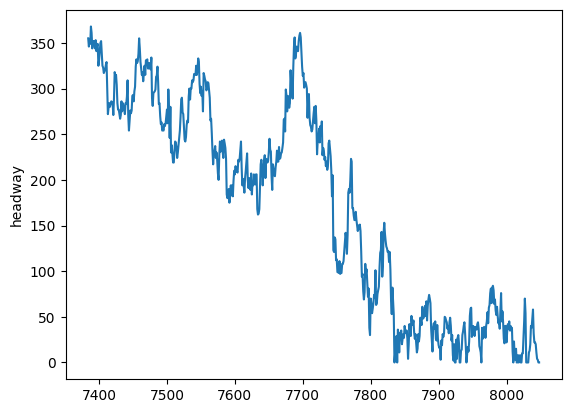

In [178]:
sns.lineplot(headway[(headway['train_id']==5)&(headway['rep']==2)].headway)

In [62]:
station = y*(int(len(x)/len(y))) + y[:len(x)%len(y)]


In [69]:
lst = []
lst_sim = []
for num in range(1, 11):
    blue_sim = Sim(network=blue_network, until=72000, distribution=scipy.stats.burr, dispatch=num, repetition=3, loop_time=2400)
    blue_sim.run()
    df = blue_sim.df
    depatch = (2400/num)
    sim_rate = df['frequency'].mean().item()
    lst.append((num,round((depatch-sim_rate)/depatch,2)))
    lst_sim.append(sim_rate)
    

100%|██████████| 3/3 [00:14<00:00,  4.91s/it]


In [9]:
l = [val for _, val in lst]

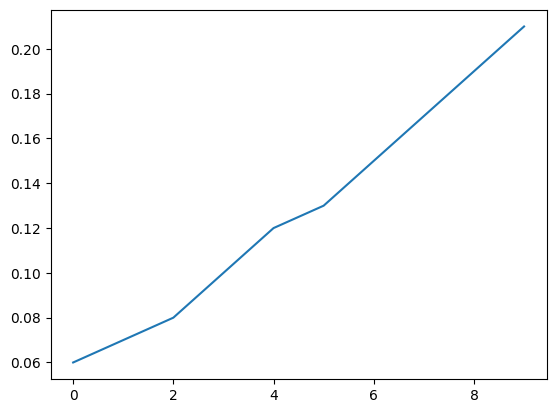

In [10]:
plt.plot(l)

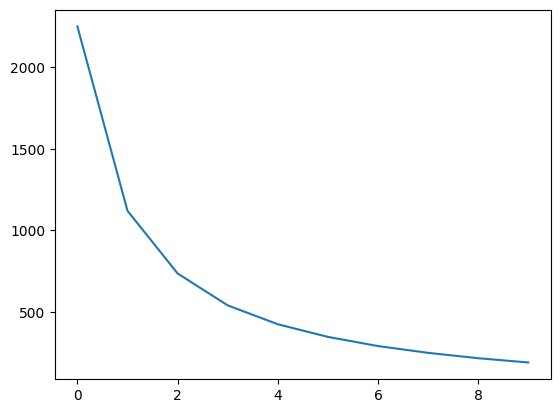

In [11]:
plt.plot(lst_sim)

# Delay Propagation

In [15]:
class SimDelayProp(Sim):

    def some_new_method(self):
        pass 


In [17]:
blue_delay = SimDelayProp(network=blue_network, until=72000, distribution=scipy.stats.burr, dispatch=1, repetition=1, loop_time=2400)

In [18]:
dir(blue_delay)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_empty_station_stats',
 '_try_serve',
 'df',
 'dispatch',
 'dispatch_trains',
 'distribution',
 'fresh_state',
 'get_stat_df',
 'handle_arrive',
 'handle_depart',
 'loop_time',
 'network',
 'push',
 'repetition',
 'run',
 'sample',
 'some_new_method',
 'until']